In [28]:
import os
import glob
from source.dataset import CombinedDataset
import glob
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [29]:
pt_files = glob.glob(os.path.join("data/pt_std_p4/10002", "*.pt"))
targets = {"E_nu": [], "pT_nu": [], "eta_nu": [], "phi_nu": [],
           "E_lep": [], "pT_lep": [], "eta_lep": [], "phi_lep": [],
           "E_jet": [], "pT_jet": [], "eta_jet": [], "phi_jet": [],
           "E_miss": [], "pT_miss": [], "eta_miss": [], "phi_miss": []}

In [30]:
dataloader = CombinedDataset(pt_files)

In [31]:
for event in tqdm(dataloader):
    for key in targets.keys():
        targets[key].append(event[key].item())
targets = {k: np.asarray(v) for k, v in targets.items()}

100%|██████████| 85927/85927 [00:02<00:00, 41154.06it/s]


In [32]:
print(targets["E_nu"])

[0.83256    0.046783   0.45991999 ... 0.70616001 0.47387001 0.87959999]


In [33]:
# print(targets["p_lep"])

In [34]:


def plot_pairwise_2dhists(targets, bins=50, cmap="viridis"):
    keys = list(targets.keys())
    n = len(keys)

    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    
    # Convert to numpy arrays
    data = {k: np.asarray(v) for k, v in targets.items()}

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i < j:
                # Upper triangle: turn off
                ax.axis("off")
                continue

            x = data[keys[j]]
            y = data[keys[i]]

            if i == j:
                # Diagonal: 1D histogram
                ax.hist(x, bins=bins, histtype="stepfilled", alpha=0.7)
            else:
                # Lower triangle: 2D histogram
                h = ax.hist2d(x, y, bins=bins, cmap=cmap)

            # Labels only on outer axes
            if i == n - 1:
                ax.set_xlabel(f"Log10 {keys[j]}")
            else:
                ax.set_xticklabels([])

            if j == 0:
                ax.set_ylabel(f"Log10 {keys[i]}")
            else:
                ax.set_yticklabels([])

    plt.tight_layout()
    return fig, axes

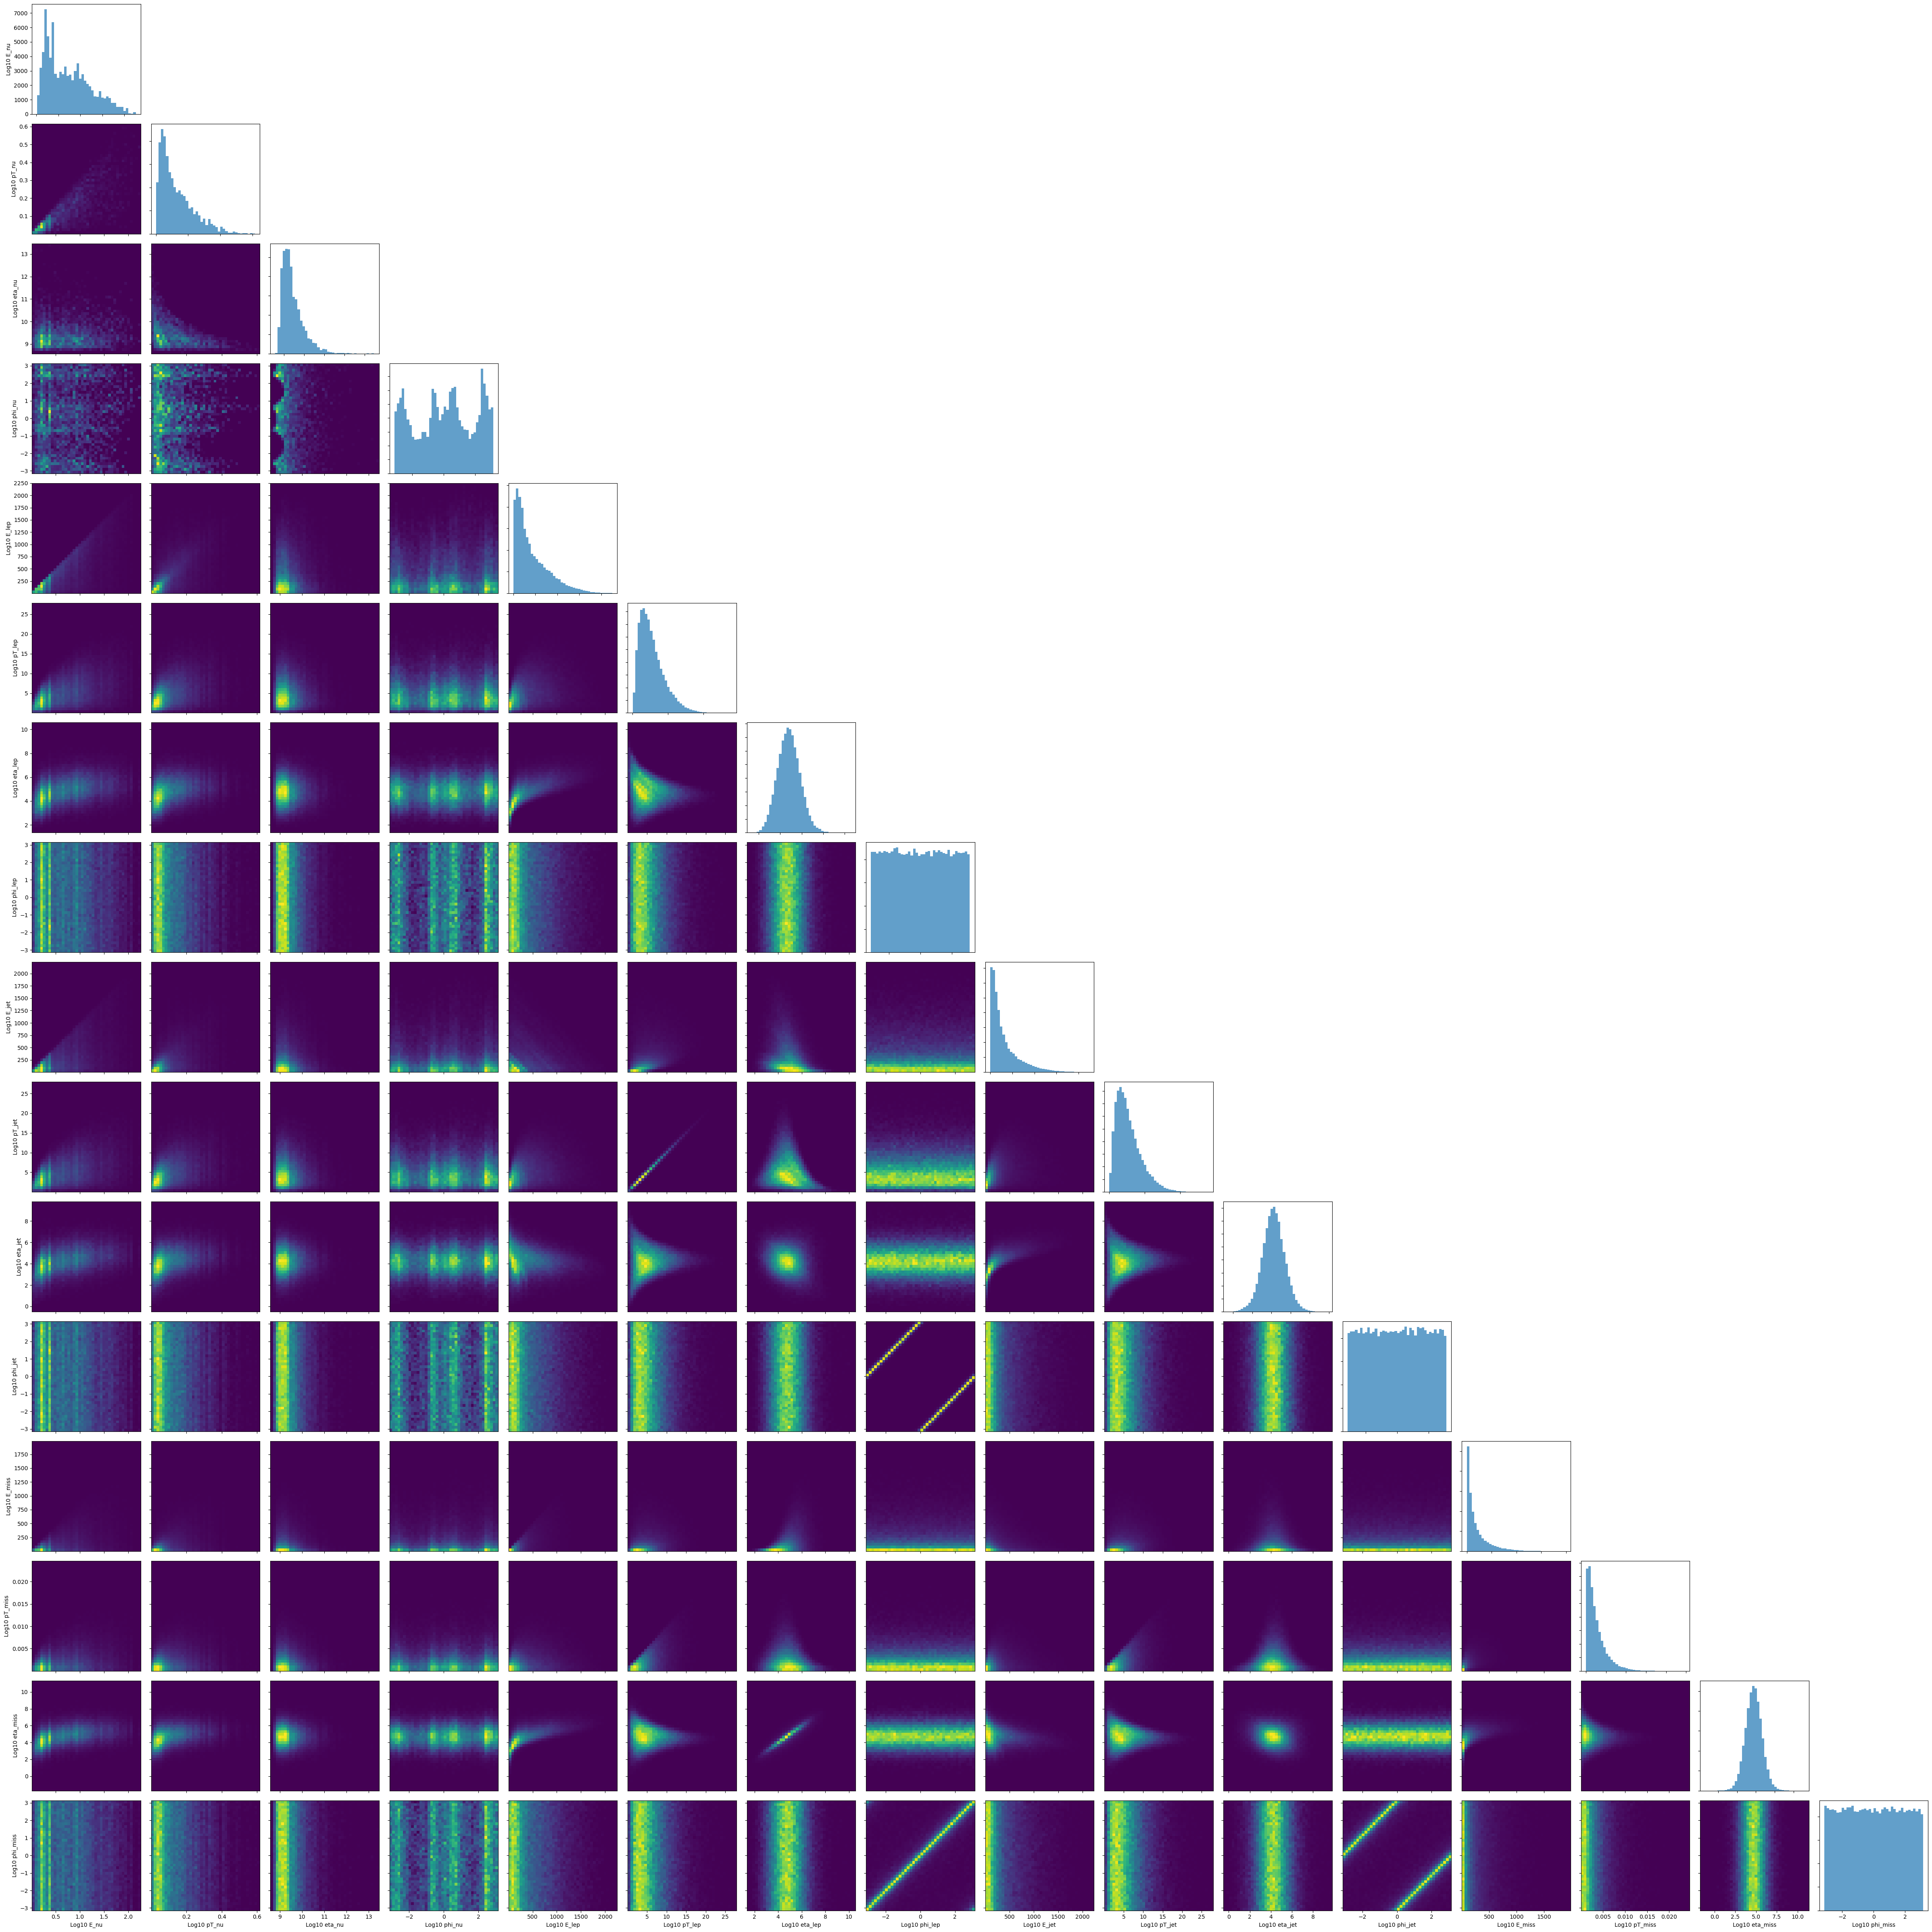

In [35]:
fig, axes = plot_pairwise_2dhists(targets, bins=40)
plt.show()

In [36]:
for var_name, values in targets.items():
    mean = np.mean(values)
    std = np.std(values)
    print(f"{var_name}:")
    print(f"\tmean: {mean:.3f}")
    print(f"\tstd: {std:.3f}")

E_nu:
	mean: 0.725
	std: 0.496
pT_nu:
	mean: 0.128
	std: 0.105
eta_nu:
	mean: 9.429
	std: 0.530
phi_nu:
	mean: 0.088
	std: 1.857
E_lep:
	mean: 426.621
	std: 378.470
pT_lep:
	mean: 5.458
	std: 3.544
eta_lep:
	mean: 4.810
	std: 1.037
phi_lep:
	mean: -0.006
	std: 1.815
E_jet:
	mean: 314.249
	std: 324.885
pT_jet:
	mean: 5.466
	std: 3.546
eta_jet:
	mean: 4.231
	std: 1.166
phi_jet:
	mean: 0.002
	std: 1.812
E_miss:
	mean: 196.781
	std: 233.885
pT_miss:
	mean: 0.003
	std: 0.002
eta_miss:
	mean: 4.712
	std: 1.097
phi_miss:
	mean: -0.009
	std: 1.814
